In [1]:
### building first, simple CNN baseline for protein stability prediction based on wt & mut seq ###

In [131]:
### 1. imports


# basic functionality
import os 
import numpy as np
import pandas as pd
import scipy
import sklearn.metrics as skmetrics

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import lightning as L

import torchmetrics
from torchmetrics.regression import PearsonCorrCoef

In [132]:
### running on gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [133]:
### 2. Dataloading ###

aa_alphabet = 'ACDEFGHIKLMNPQRSTVWY' # amino acid alphabet
aa_to_int = {aa: i for i, aa in enumerate(aa_alphabet)} # mapping from amino acid to number

# function to one hot encode sequence
def one_hot_encode(sequence):
    # initialize a zero matrix of shape (len(sequence), len(amino_acids))
    one_hot = torch.zeros(len(sequence), len(aa_alphabet))
    for i, aa in enumerate(sequence):
        # set the column corresponding to the amino acid to 1
        one_hot[i].scatter_(0, torch.tensor([aa_to_int[aa]]), 1)
    return one_hot



# sequence data, comes already batched, so treat accordingly in dataloader (batch_size=1)
class SequenceData(Dataset):
    def __init__(self, csv_file, label_col="ddG_ML"):
        """
        Initializes the dataset. 
        input:
            csv_file: path to the relevant data file, eg. "/home/data/mega_train.csv"
        """
        self.df = pd.read_csv(csv_file, sep=",")
        self.label_col = label_col
        # only have mutation rows
        self.df = self.df[self.df.mut_type!="wt"]
        # process the mutation row
        self.df["mutation_pos"] = self.df["mut_type"].apply(lambda x: int(x[1:-1])-1) # make position start at zero
        self.df["mutation_to"] = self.df["mut_type"].apply(lambda x: aa_to_int[x[-1]]) # give numerical label to mutation

        # group by wild type
        self.df = self.df.groupby("WT_name").agg(list)
        # get wild type names
        self.wt_names = self.df.index.values
        # precompute one-hot encoding for faster training
        self.encoded_seqs = {}
        for wt_name in self.wt_names:
            # get the correct row
            mut_row = self.df.loc[wt_name]
            seq = mut_row["wt_seq"][0]
            self.encoded_seqs[wt_name] = one_hot_encode(seq)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get the wild type name
        wt_name = self.wt_names[idx]
        # get the correct row
        mut_row = self.df.loc[wt_name]
        # get the wt sequence in one hot encoding
        sequence_encoding = self.encoded_seqs[wt_name]
            # dimensions (len, 20)

        # create mask and target tensors
        mask = torch.zeros((1, len(sequence_encoding),20)) # will be 1 where we have a measurement 
        target = torch.zeros((1, len(sequence_encoding),20)) # ddg values
            # remember batch size = 1
        # all mutations from df
        positions = torch.tensor(mut_row["mutation_pos"])
        amino_acids = torch.tensor(mut_row["mutation_to"])
        # get the labels
        labels = torch.tensor(mut_row[self.label_col])

        for i in range(len(sequence_encoding)):
            mask[0,i,amino_acids[positions==i]] = 1 # one where we have data (i.e. ddG measurement)
            target[0,i,amino_acids[positions==i]] = labels[positions==i] # fill with ddG values
        
        # returns encoded sequence, mask and target sequence 
        return {"sequence": sequence_encoding[None,:,:].float(), "mask": mask, "labels": target}


        # use this structure to
        # - predict ddG for all possible mutations
        # - mask serves to only compute loss at positions where experimental data exists

In [134]:
# usage
dataset_train = SequenceData('mega_train.csv')
dataset_val= SequenceData('mega_val.csv')
# dataset_test = SequenceData('project_data/mega_test.csv') # only once available

# use batch_size=1 bc we treat each sequence as one batch
dataloader_val = DataLoader(dataset_val, batch_size=1, shuffle=False)
dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
# dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

In [135]:
### 3. Data exploration ###

print('training data')
print(type(dataset_train))
# custom Pytorch Dataset object

print(len(dataset_train))
# nb of proteins

exemplary_protein = dataset_train[0]
print('exemplary datapoint (wt protein 0), which will be fed into CNN as one input:')
print(type(exemplary_protein))

print({k: v.shape for k,v in exemplary_protein.items()})
    # IMPORTANT: only 'sequence' will be used for model training, 'mask' and 'labels' both serve loss computation


print('\nvalidation data')
print(type(dataset_val))
# custom Pytorch Dataset object

print(len(dataset_val))
# nb of proteins

exemplary_protein = dataset_val[0]
print('exemplary datapoint (wt protein 0), which will be fed into CNN as one input:')
print(type(exemplary_protein))

print({k: v.shape for k,v in exemplary_protein.items()})
    # IMPORTANT: only 'sequence' will be used for model training, 'mask' and 'labels' both serve loss computation


training data
<class '__main__.SequenceData'>
239
exemplary datapoint (wt protein 0), which will be fed into CNN as one input:
<class 'dict'>
{'sequence': torch.Size([1, 63, 20]), 'mask': torch.Size([1, 63, 20]), 'labels': torch.Size([1, 63, 20])}

validation data
<class '__main__.SequenceData'>
31
exemplary datapoint (wt protein 0), which will be fed into CNN as one input:
<class 'dict'>
{'sequence': torch.Size([1, 39, 20]), 'mask': torch.Size([1, 39, 20]), 'labels': torch.Size([1, 39, 20])}


In [136]:
print(dataloader_train)

print(type(dataset_train))

<class '__main__.SequenceData'>


In [137]:
### 4. define CNN model architecture ###

# create new model class that inherits all properties from the torch.nn.Module
class simplecnn(nn.Module):
    # initialize
    def __init__(self):
        # load parent module
        super(simplecnn, self).__init__()

        # ingredients
        self.conv1 = nn.Conv1d(in_channels=20, out_channels=128,kernel_size=11,padding=5)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=128,kernel_size=7,padding=3)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=64,kernel_size=5,padding=2)
        self.convlinear = nn.Conv1d(in_channels=64, out_channels=64,kernel_size=1)
        self.output = nn.Conv1d(in_channels=64, out_channels=20,kernel_size=1)

        # recipe
    def forward(self, x):
        
        x = x.squeeze(0) # goal: 1x1xlen(seq)x20 --> 1xlen(seq)x20
        x = x.permute(0,2,1) # permute dimensions from 1x20xlen(seq) to 20x1x63 (needed for proper kernel convolutoin)

        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        x = F.relu(self.convlinear(x))
        x = self.output(x)
        

        x = x.permute (0,2,1) # permute dimensions back to 1xlen(seq)x20
        

        return x
        

In [138]:
### 5. wrap model into lightning for training ###

class Litsimplecnn(L.LightningModule):
    def __init__(self, learning_rate):
        super().__init__()
        #self.save_hyperparameters()
        
        #self.model = simplecnn(hidden=hidden)
        self.model = simplecnn()
        self.lr = learning_rate

        self.loss_function = nn.MSELoss()
        #self.loss_function = nn.SmoothL1Loss(beta=1.0)
        self.mae = torchmetrics.MeanAbsoluteError() # accuracy only suited for classification (discrete outcome variable)
        #track different accuracy and mae,... metrics here

    def onlyrelevantddG(self, batch):
        '''
        returns: pred_ddg: predicted ddG for the mutation in each sample; y: true experimental ddG
        '''
        x = batch["sequence"] # --> torch.Size([1, 1, 39, 20])
        
        
        mask = batch["mask"]# --> torch.Size([1, 1, 39, 20])
    
        
        true_ddG = batch["labels"] # --> torch.Size([1, 1, 39, 20])
        true_ddG = true_ddG[mask==1] ### --> ERROR HAPPENS HERE: true_ddG is flattened to vector of size 686 !!! (instead of same dimensions as input)
        
        pred_all = self.model(x)

        pred_ddG = pred_all[mask.squeeze(0)==1]
        #true_ddG = true_ddG[mask==1]
        '''
        preds =[]
        all_y = []

        preds.append(prediction[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
        all_y.append(target[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
        '''

        return pred_ddG, true_ddG

        
        
    def training_step(self, batch, batch_idx):
        
        pred_ddG, true_ddG = self.onlyrelevantddG(batch)

        loss = self.loss_function(pred_ddG, true_ddG)
        mae = self.mae(pred_ddG, true_ddG)

        self.log("train loss:", loss, on_epoch=True, prog_bar=True)
        self.log("train mae:", mae, on_epoch=True, prog_bar=True)
        
        return loss



    def validation_step (self, batch, batch_idx):

        pred_ddG, true_ddG = self.onlyrelevantddG(batch)
        
        loss = self.loss_function(pred_ddG, true_ddG)
        
        mae = self.mae(pred_ddG, true_ddG)
        

        self.log("val loss:", loss, on_epoch=True, prog_bar=True)
        self.log("val mae:", mae, on_epoch=True, prog_bar=True)

        return loss

        

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, betas = (0.9,0.99), eps = 1e-8,weight_decay=0.01)
        


In [139]:
### create a tensorboard session ###
# new tab should open in your browser
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/

Reusing TensorBoard on port 6006 (pid 7300), started 1:16:00 ago. (Use '!kill 7300' to kill it.)

In [140]:
### 6. train model ###


# initialize model (always needed to have a new model for training)
lightning_model = Litsimplecnn(learning_rate=1e-4)


# instantiate lightning trainer
trainer = L.Trainer(max_epochs=25, log_every_n_steps=1)


# train
trainer.fit(lightning_model, dataloader_train, dataloader_val)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | model         | simplecnn         | 189 K  | train | 0    
1 | loss_function | MSELoss           | 0      | train | 0    
2 | mae           | MeanAbsoluteError | 0      | train | 0    
--------------------------------------------------------------------
189 K     Trainable params
0         Non-trainable p

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=25` reached.


RMSE: 0.5583537817001343
Pearson r: PearsonRResult(statistic=0.6031649, pvalue=0.0)
Spearman r: SignificanceResult(statistic=0.567592216321948, pvalue=0.0)


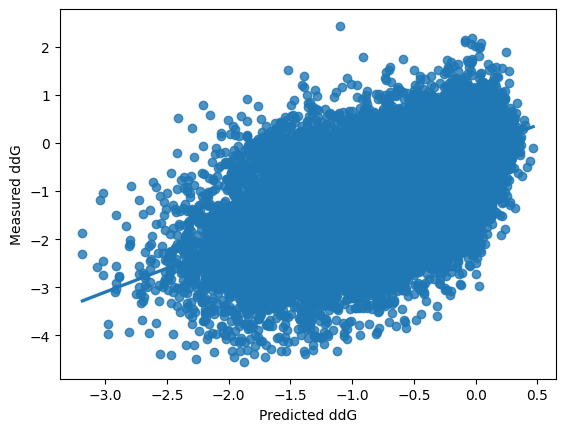

In [141]:
preds =[]
all_y = []

for batch in dataloader_val:
    # read from batch
    x = batch["sequence"]#[0]
    mask = batch["mask"]#[0] #instead of squeezing later
    target = batch["labels"]#[0]
    ## adjust to work with your model
    # predict
    prediction = lightning_model.model(x)
    preds.append(prediction[mask.squeeze(0)==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
    all_y.append(target[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence

# concatenate and plot
preds= np.concatenate(preds)
all_y = np.concatenate(all_y)

sns.regplot(x=preds,y=all_y)
plt.xlabel("Predicted ddG")
plt.ylabel("Measured ddG")

# get RMSE, Pearson and Spearman correlation 
print("RMSE:", skmetrics.mean_squared_error(all_y, preds))
print("Pearson r:", scipy.stats.pearsonr(preds, all_y))
print("Spearman r:", scipy.stats.spearmanr(preds, all_y))

In [142]:
### 7. feed single sequence into model visualize output tensor ###

model = lightning_model.model  # extract pure CNN
model.eval()
model.to(device)

# prepare input
sequence = "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"  # example sequence #maybe use SequenceData

encoded = one_hot_encode(sequence)        # (L, 20)
encoded = encoded[None, :, :]             # (1, L, 20)
encoded = encoded[None, :, :, :]          # (1, 1, L, 20)  <-- match training input
encoded = encoded.float().to(device)
# get model output
with torch.no_grad():
    output = model(encoded)
print(output.shape)
# torch.Size([1, L, 20])
ddg_matrix = output[0].cpu().numpy() # shape (L, 20), what position is what?
# visualize ddG matrix

torch.Size([1, 76, 20])


In [143]:
ddg_matrix
ddg_matrix[1,9]

0.18088965

In [144]:
def mutation_dict(sequence, ddg_matrix):
    results = {}
    for i, wt_aa in enumerate(sequence):
        for j in range(20):
            mut_aa = aa_alphabet[j]
            #if mut_aa != wt_aa: # if uncommenting the if statement: need to indent below line
            results[f"{wt_aa}{i+1}{mut_aa}"] = ddg_matrix[i, j].item()
    return results

x = mutation_dict(sequence, ddg_matrix)

len(x)

1520

In [145]:
position = 10
aa_index = aa_to_int["A"]

predicted_ddg = output[0, position, aa_index].item()

print("Predicted ΔΔG:", predicted_ddg)

Predicted ΔΔG: -0.02938617393374443


In [146]:
wt_sequence = "MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFVRDFAGDGLFTSWTHEKNWKKAHNILLPSFSQQAMKGYHAMMVDIAVQLVQKWERLNADEHIEVPEDMTRLTLDTIGLCGFNYRFNSFYRDQPHPFITSMVRALDEAMNKLQRANPDDPAYDENKRQFQEDIKVMNDLVDKIIADRKASGEQSDDLLTHMLNGKDPETGEPLDDENIRYQIITFLIAGHETTSGLLSFALYFLVKNPHVLQKAAEEAARVLVDPVPSYKQVKQLKYVGMVLNEALRLWPTAPAFSLYAKEDTVLGGEYPLEKGDELMVLIPQLHRDKTIWGDDVEEFRPERFENPSAIPQHAFKPFGNGQRACIGQQFALHEATLVLGMMLKHFDFEDHTNYELDIKETLTLKPEGFVVKAKSKKIPLGGIPSPSTEQSAKKVRKKAENAHNTPLLVLYGSNMGTAEGTARDLADIAMSKGFAPQVATLDSHAGNLPREGAVLIVTASYNGHPPDNAKQFVDWLDQASADEVKGVRYSVFGCGDKNWATTYQKVPAFIDETLAAKGAENIADRGEADASDDFEGTYEEWREHMWSDVAAYFNLDIENSEDNKSTLSLQFVDSAADMPLAKMHGAFSTNVVASKELQQPGSARSTRHLEIELPKEASYQEGDHLGVIPRNYEGIVNRVTARFGLDASQQIRLEAEEEKLAHLPLAKTVSVEELLQYVELQDPVTRTQLRAMAAKTVCPPHKVELEALLEKQAYKEQVLAKRLTMLELLEKYPACEMKFSEFIALLPSIRPRYYSISSSPRVDEKQASITVSVVSGEAWSGYGEYKGIASNYLAELQEGDTITCFISTPQSEFTLPKDPETPLIMVGPGTGVAPFRGFVQARKQLKEQGQSLGEAHLYFGCRSPHEDYLYQEELENAQSEGIITLHTAFSRMPNQPKTYVQHVMEQDGKKLIELLDQGAHFYICGDGSQMAPAVEATLMKSYADVHQVSEADARLWLQQLEEKGRYAKDVWAG"

In [147]:
wt_sequence[78]

'V'

In [148]:
def apply_mutation_step(sequence, mutations, shift=1, validate_wt=False):
    seq_list = list(sequence)
    
    if validate_wt:
        for mutation in mutations:
            wt_aa = mutation[0]
            pos = int(mutation[1:-1]) - 1 + shift
            if seq_list[pos] != wt_aa:
                raise ValueError(
                    f"Mismatch at position {pos+1}: expected {seq_list[pos]}, got {wt_aa}"
                )
    
    # Apply all mutations
    for mutation in mutations:
        mut_aa = mutation[-1]
        pos = int(mutation[1:-1]) - 1 + shift
        seq_list[pos] = mut_aa
    
    return "".join(seq_list)


def build_mutation_trajectory(wt_sequence, mutation_steps, shift=1):
    """
    Apply a list of mutation steps sequentially and save all intermediates.
    
    Returns: list of sequences [WT, step1_seq, step2_seq, ..., final_seq]
    """
    sequences = [wt_sequence]
    current_seq = wt_sequence
    
    for step in mutation_steps:
        current_seq = apply_mutation_step(current_seq, step, shift=shift)
        sequences.append(current_seq)
    
    return sequences

In [149]:
mutation_steps = [
    ["V78A", "H138Y", "T175I", "V178I", "A184V", "H236Q", "E252G", "R255S", "A290V", "A295T", "L353V"],
    ["Y138H", "I178V", "F205C", "S226R", "T295A"],
    ["R47C", "A78F", "A82S", "K94I", "P142S", "A328F"],
    ["L52I", "I366V"],
    ["L188P"],
    ["A74S"],
    ["V184A"],
    ["A74E", "S82G", "A184V", "G443A"]
]

trajectory = build_mutation_trajectory(wt_sequence, mutation_steps, shift=1)

# Print first few steps to verify
print("WT:", trajectory[0][:80], "...")
print("After step 1:", trajectory[1][:80], "...")
print("After step 2:", trajectory[2][:80], "...")
print("After step 3:", trajectory[3][:80], "...")
print("Total sequences saved:", len(trajectory))

WT: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFVR ...
After step 1: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFAR ...
After step 2: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFAR ...
After step 3: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGCVTRYLSSQRLIKEACDESRFDKNLSQALKFFR ...
Total sequences saved: 9


In [150]:
print(trajectory[7][82])
print(trajectory[8][82])

S
G


In [151]:
def apply_single_mutation(sequence, mutation, shift=1):
    """
    Apply a single mutation to a protein sequence.
    
    Parameters:
        sequence : str
            The current protein sequence.
        mutation : str
            Mutation in format "A74S" (original AA, position 1-based, new AA).
        shift : int, optional
            Offset to adjust mutation numbering (default 0).

    Returns:
        str : the mutated sequence
    """
    seq_list = list(sequence)
    
    wt_aa = mutation[0]
    mut_aa = mutation[-1]
    pos = int(mutation[1:-1]) - 1 + shift  # convert to 0-based index
    
    # Optional validation: check that current residue matches expected WT
    if seq_list[pos] != wt_aa:
        raise ValueError(
            f"Mismatch at position {pos+1}: expected {seq_list[pos]}, got {wt_aa}"
        )
    
    # Apply mutation
    seq_list[pos] = mut_aa
    
    return "".join(seq_list)

import torch

def predict_ddg_for_mutation(sequence, mutation, model, device, aa_to_int, shift=1):
    """
    Predict ΔΔG for a single mutation on a given sequence using a CNN.
    
    Parameters:
        sequence : str
            The protein sequence (WT or already mutated).
        mutation : str
            Mutation string like "A74S".
        model : torch.nn.Module
            Trained CNN model (pure model, not Lightning wrapper).
        device : torch.device
            e.g., torch.device('cuda') or torch.device('cpu')
        aa_to_int : dict
            Mapping of amino acid letters to indices (0-19)
        shift : int
            Position shift if mutation numbering is offset from 1 (default 1)
    
    Returns:
        float : predicted ΔΔG for this mutation
    """
    model.eval()
    
    # --- Encode sequence ---
    encoded = one_hot_encode(sequence)           # (L, 20)
    encoded = encoded[None, :, :] # (1, L, 20)
    encoded = encoded[None, :, :, :].float().to(device)
    # --- Forward pass through CNN ---
    with torch.no_grad():
        output = model(encoded)  # shape: (1, L, 20)
    
    ddg_matrix = output[0].cpu().numpy()  # (L, 20)
    
    # --- Extract mutation info ---
    pos = int(mutation[1:-1])
    mut_aa = mutation[-1]
    aa_idx = aa_to_int[mut_aa]
    
    ddg_val = ddg_matrix[pos, aa_idx]
    return ddg_val

In [152]:
zy = apply_single_mutation(trajectory[3],mutation_steps[3][0], shift=1) # ["L52I", "I366V"],
print(trajectory[3][52])
print(zy[52])
encoded=one_hot_encode(zy)
encoded = encoded[None, :, :]             # (1, L, 20)
encoded = encoded[None, :, :, :]          # (1, 1, L, 20)  <-- match training input
encoded = encoded.float().to(device)
with torch.no_grad():
    output = model(encoded)
print(output.shape)
ddg_matrixzy = output[0].cpu().numpy()

print(ddg_matrixzy[366,17])

L
I
torch.Size([1, 1049, 20])
-0.5329627


In [153]:
zy = apply_single_mutation(wt_sequence,mutation_steps[0][0], shift=1)
print(wt_sequence[78])
print(zy[78])
encoded=one_hot_encode(zy)
encoded = encoded[None, :, :]             # (1, L, 20)
encoded = encoded[None, :, :, :]          # (1, 1, L, 20)  <-- match training input
encoded = encoded.float().to(device)
with torch.no_grad():
    output = model(encoded)
print(output.shape)
ddg_matrixzy = output[0].cpu().numpy()

print(ddg_matrixzy[138,19])

V
A
torch.Size([1, 1049, 20])
-0.04575772


In [154]:
### 7. feed single sequence into model visualize output tensor ###

model = lightning_model.model  # extract pure CNN
model.eval()
model.to(device)

# prepare input
sequence = trajectory[4]  # example sequence #maybe use SequenceData

encoded = one_hot_encode(sequence)        # (L, 20)
encoded = encoded[None, :, :]             # (1, L, 20)
encoded = encoded[None, :, :, :]          # (1, 1, L, 20)  <-- match training input
encoded = encoded.float().to(device)
# get model output
with torch.no_grad():
    output = model(encoded)
print(output.shape)
# torch.Size([1, L, 20])
ddg_matrix = output[0].cpu().numpy() # shape (L, 20), what position is what?
# visualize ddG matrix
mutation = "L188P"
pos = int(mutation[1:-1])    # convert 1-based to 0-based index 
mut_aa = mutation[-1]
aa_idx = aa_to_int[mut_aa]

ddg_value = ddg_matrix[pos, aa_idx]
print(f"Predicted ΔΔG for {mutation}: {ddg_value:.3f}")

print(ddg_matrix[188, 12])
print(trajectory[5][188])
zxy=predict_ddg_for_mutation(trajectory[4],mutation_steps[4][0], model, device, aa_to_int)
print(zxy)

torch.Size([1, 1049, 20])
Predicted ΔΔG for L188P: -2.271
-2.2709737
P
-2.2709737


In [155]:
##################################################################################################################

In [164]:
def get_ddg_matrices_for_trajectory(trajectory, model, device):
    """
    Compute the full ΔΔG matrix (all positions × all amino acids) for every sequence in trajectory.
    
    Parameters:
        trajectory : list of str
            List of sequences (WT + intermediate sequences)
        model : torch.nn.Module
            Trained CNN
        device : torch.device
    
    Returns:
        list of np.ndarray
            Each element is a matrix of shape (L, 20) for that sequence
    """
    model.eval()
    ddg_matrices = []
    
    for seq in trajectory[0:8]:
        # Encode sequence
        encoded = one_hot_encode(seq)  # (1, L, 20)
        encoded = encoded[None, :, :]  # (1, L, 20)
        encoded = encoded[None, :, :, :].float().to(device)  # (1, L, 20)
        
        with torch.no_grad():
            output = model(encoded)  # (1, L, 20)
        
        ddg_matrix = output[0].cpu().numpy()  # shape (L, 20)
        ddg_matrices.append(ddg_matrix)
    
    return ddg_matrices

In [165]:
ddg_matrices = get_ddg_matrices_for_trajectory(trajectory, model, device)
#print(ddg_matrices)
print(len(ddg_matrices))

8


In [166]:
step_ddg = []
for step_idx, step_mutations in enumerate(mutation_steps):
    ddg_matrix = ddg_matrices[step_idx]  # sequence after previous step
    step_dict = {}
    for mut in step_mutations:
        pos = int(mut[1:-1])
        aa_idx = aa_to_int[mut[-1]]
        step_dict[mut] = ddg_matrix[pos, aa_idx]
    step_ddg.append(step_dict)

In [167]:
print(step_ddg)
print(step_ddg[4])

[{'V78A': -1.4630576, 'H138Y': -0.04575772, 'T175I': -0.06552195, 'V178I': -0.46738818, 'A184V': -0.68159765, 'H236Q': -0.075788446, 'E252G': -0.46361044, 'R255S': -0.5858655, 'A290V': -0.6291439, 'A295T': -1.2626944, 'L353V': -0.6858464}, {'Y138H': -1.2767563, 'I178V': -0.74641585, 'F205C': -0.65194327, 'S226R': -0.20711364, 'T295A': -0.7694601}, {'R47C': -0.16856298, 'A78F': -0.73754, 'A82S': -0.72562414, 'K94I': -0.0026294212, 'P142S': -0.30963916, 'A328F': -0.43312737}, {'L52I': -0.70546585, 'I366V': -0.5329627}, {'L188P': -2.2709737}, {'A74S': -1.0955018}, {'V184A': -0.7116027}, {'A74E': -0.4955557, 'S82G': -0.70645154, 'A184V': -0.6524334, 'G443A': -0.94147784}]
{'L188P': -2.2709737}


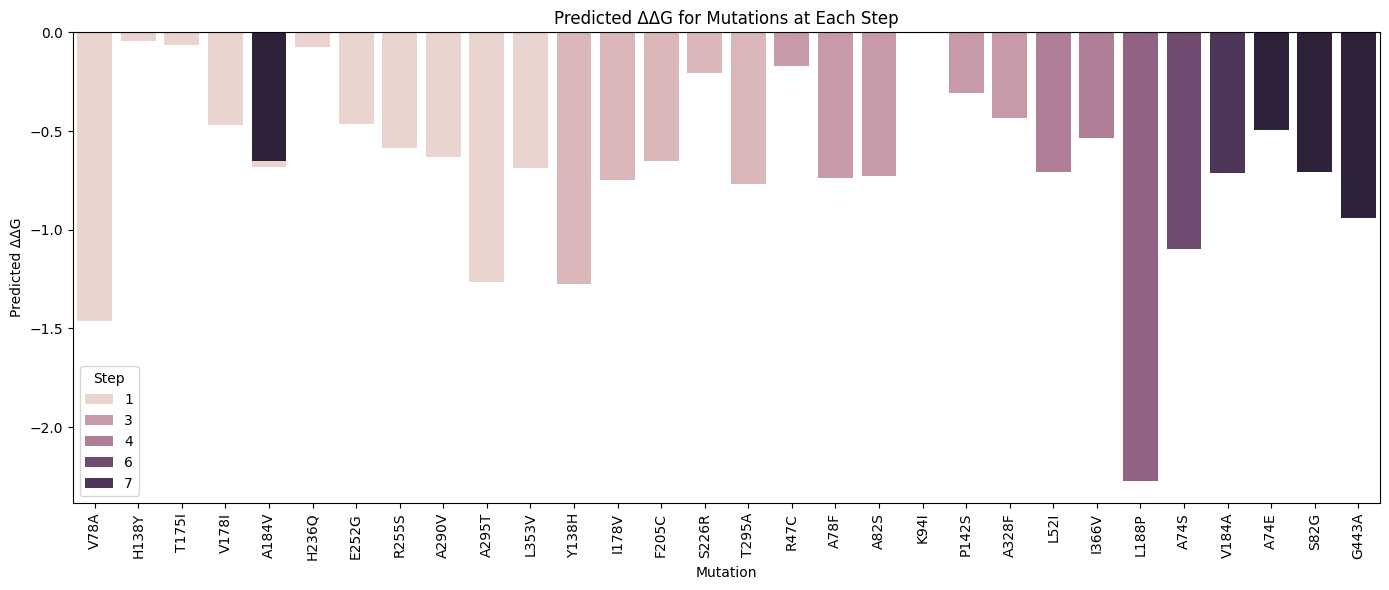

In [168]:
#Illustration:
rows = []
for step_idx, step_dict in enumerate(step_ddg):
    for mut, ddg in step_dict.items():
        rows.append({"Step": step_idx+1, "Mutation": mut, "ddG": ddg})

df = pd.DataFrame(rows)

plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Mutation", y="ddG", hue="Step", dodge=False)
plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')  # zero reference
plt.ylabel("Predicted ΔΔG")
plt.title("Predicted ΔΔG for Mutations at Each Step")
plt.legend(title="Step")
plt.tight_layout()
plt.show()

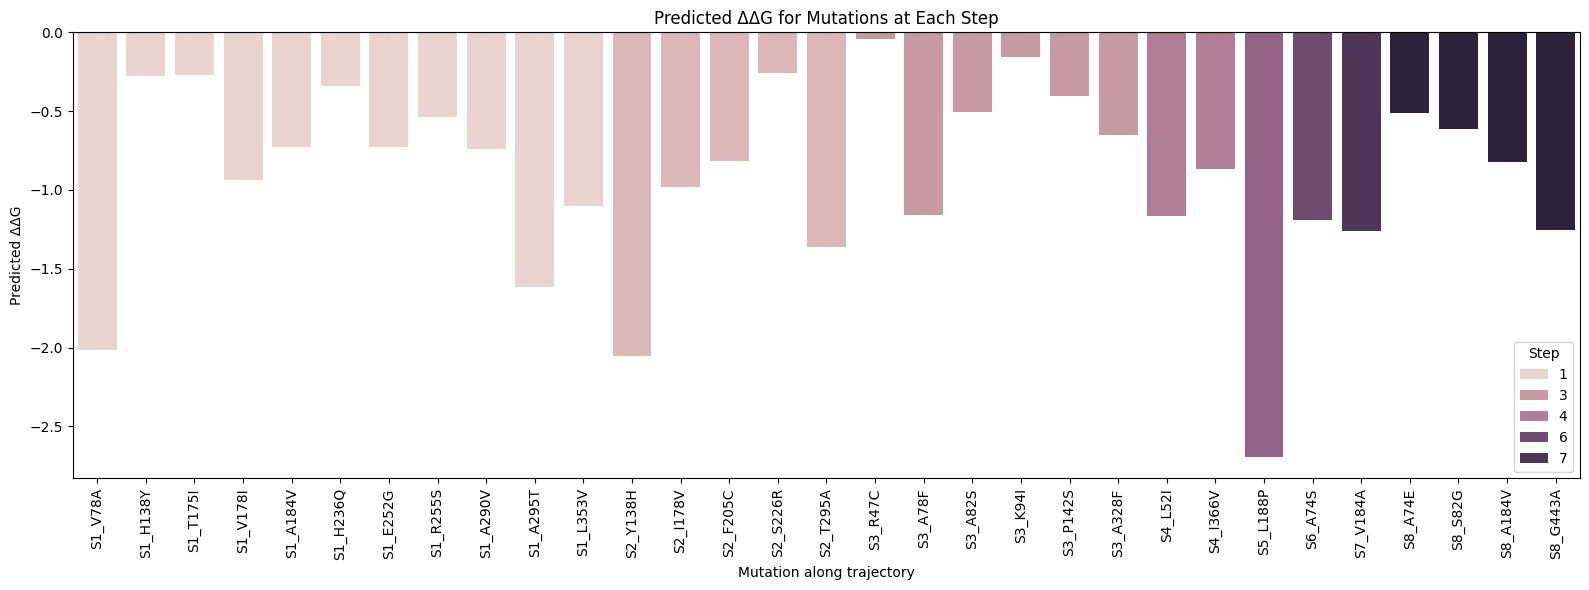

In [169]:
rows = []
for step_idx, mutations in enumerate(mutation_steps):
    step_ddg_list = mutation_specific_ddg[step_idx]  # ΔΔG for each mutation in this step
    for mut_idx, mut in enumerate(mutations):
        rows.append({
            "Step": step_idx + 1,
            "Mutation": mut,
            "ddG": step_ddg_list[mut_idx],
            "MutationStep": f"S{step_idx+1}_{mut}"  # ensures unique order even if repeated
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(16,6))

# Barplot with dodge=False; x="MutationStep" preserves order
sns.barplot(
    data=df,
    x="MutationStep",
    y="ddG",
    hue="Step",
    dodge=False
)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')  # zero reference
plt.ylabel("Predicted ΔΔG")
plt.xlabel("Mutation along trajectory")
plt.title("Predicted ΔΔG for Mutations at Each Step")
plt.legend(title="Step")
plt.tight_layout()
plt.show()

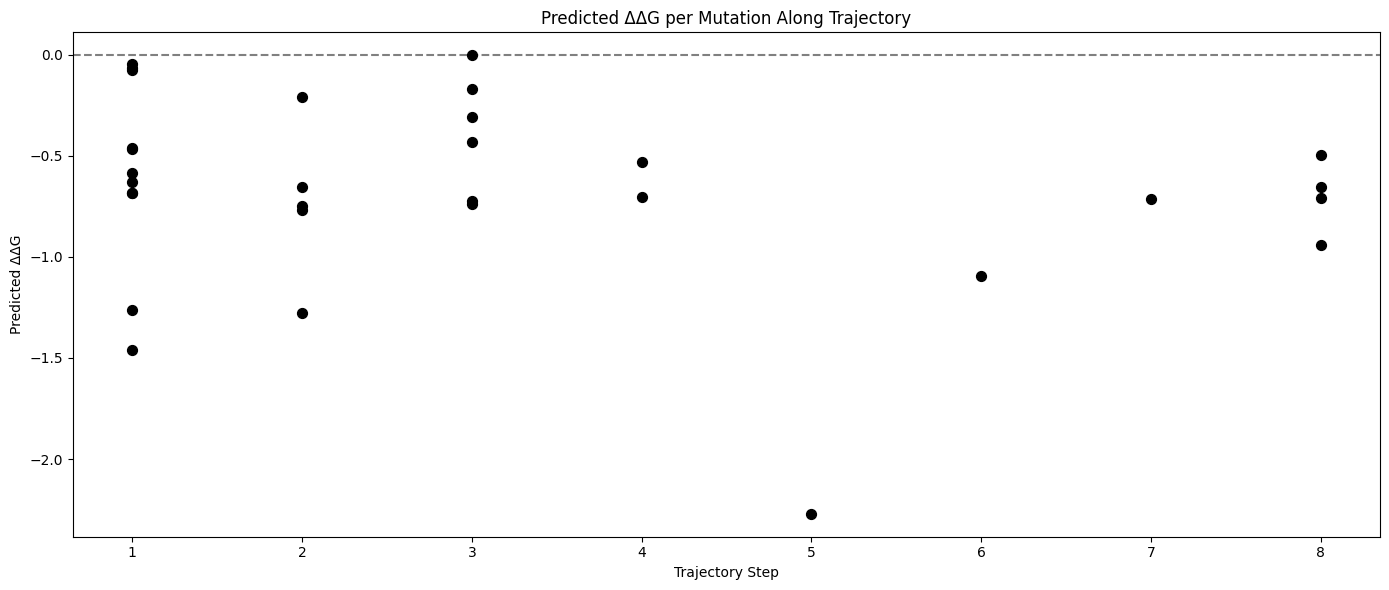

In [170]:
# Flatten step_ddg into x (step order) and y (ΔΔG)
x = []
y = []
mutation_labels = []

for step_idx, step_dict in enumerate(step_ddg):
    for mut, ddg in step_dict.items():
        x.append(step_idx + 1)      # trajectory step
        y.append(ddg)               # predicted ΔΔG
        mutation_labels.append(mut) # optional: mutation label

plt.figure(figsize=(14,6))

# Scatter plot: one point per mutation
plt.scatter(x, y, color='black', s=50, zorder=5)

# Zero reference line
plt.axhline(0, color='grey', linestyle='--', zorder=0)

plt.xticks(range(1, len(step_ddg)+1))
plt.xlabel("Trajectory Step")
plt.ylabel("Predicted ΔΔG")
plt.title("Predicted ΔΔG per Mutation Along Trajectory")

plt.tight_layout()
plt.show()

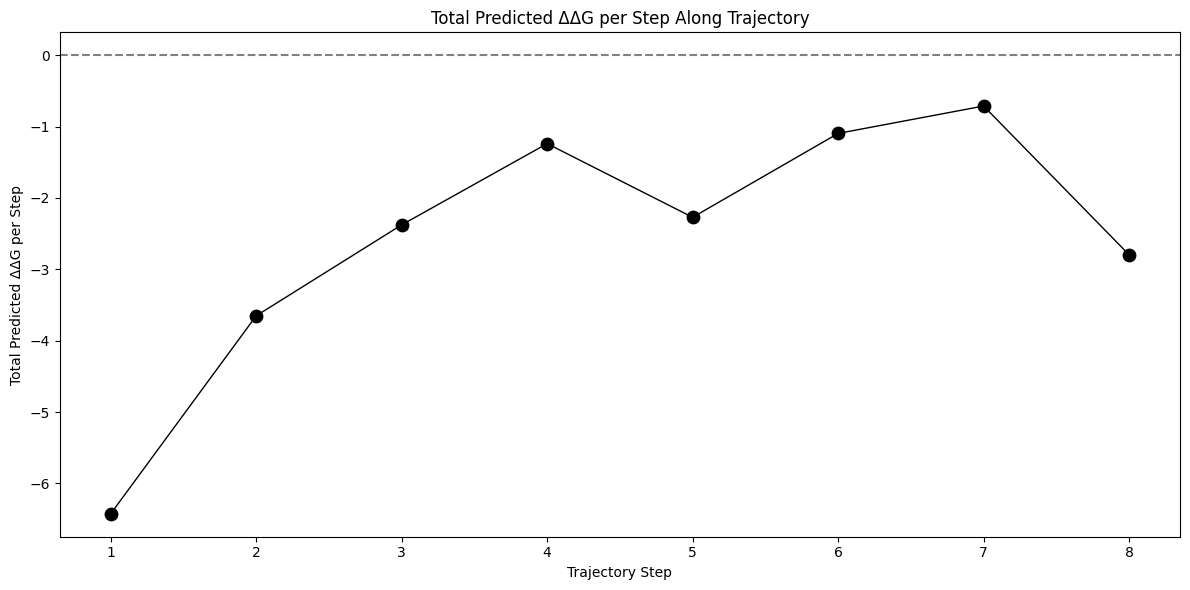

In [171]:


# Compute total ΔΔG per step
x = []
y_step_sum = []

for step_idx, step_dict in enumerate(step_ddg):
    step_sum = sum(step_dict.values())  # sum all ΔΔG values in this step
    x.append(step_idx + 1)              # step number
    y_step_sum.append(step_sum)         # total ΔΔG for this step

plt.figure(figsize=(12,6))

# Scatter plot: one point per step
plt.scatter(x, y_step_sum, color='black', s=80, zorder=5)

# Optional: line connecting points
plt.plot(x, y_step_sum, color='black', linewidth=1, zorder=4)

# Zero reference line
plt.axhline(0, color='grey', linestyle='--', zorder=0)

plt.xticks(range(1, len(step_ddg)+1))
plt.xlabel("Trajectory Step")
plt.ylabel("Total Predicted ΔΔG per Step")
plt.title("Total Predicted ΔΔG per Step Along Trajectory")
plt.tight_layout()
plt.show()

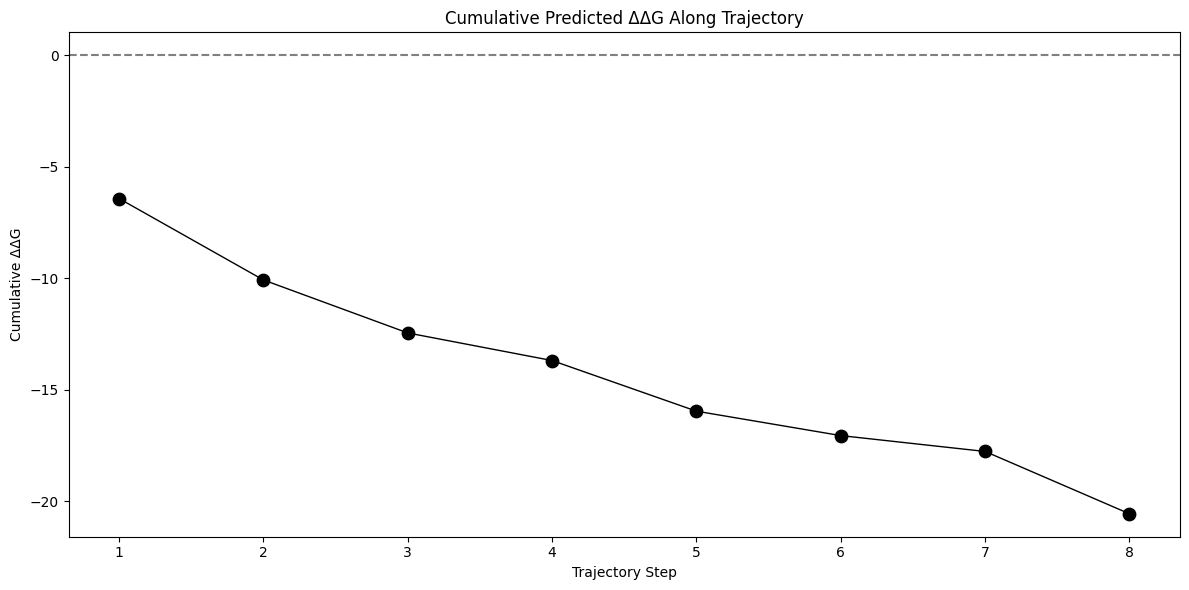

In [172]:
#Compute cumulative ΔΔG per step
x = []
y_cumulative = []

cumulative = 0
for step_idx, step_dict in enumerate(step_ddg):
    step_sum = sum(step_dict.values())   # sum of ΔΔG in this step
    cumulative += step_sum               # cumulative sum
    x.append(step_idx + 1)               # step number
    y_cumulative.append(cumulative)

plt.figure(figsize=(12,6))

# Scatter plot for cumulative ΔΔG
plt.scatter(x, y_cumulative, color='black', s=80, zorder=5)
plt.plot(x, y_cumulative, color='black', linewidth=1, zorder=4)

# Zero reference line
plt.axhline(0, color='grey', linestyle='--', zorder=0)

# Labels and title
plt.xticks(range(1, len(step_ddg)+1))
plt.xlabel("Trajectory Step")
plt.ylabel("Cumulative ΔΔG")
plt.title("Cumulative Predicted ΔΔG Along Trajectory")

plt.tight_layout()
plt.show()

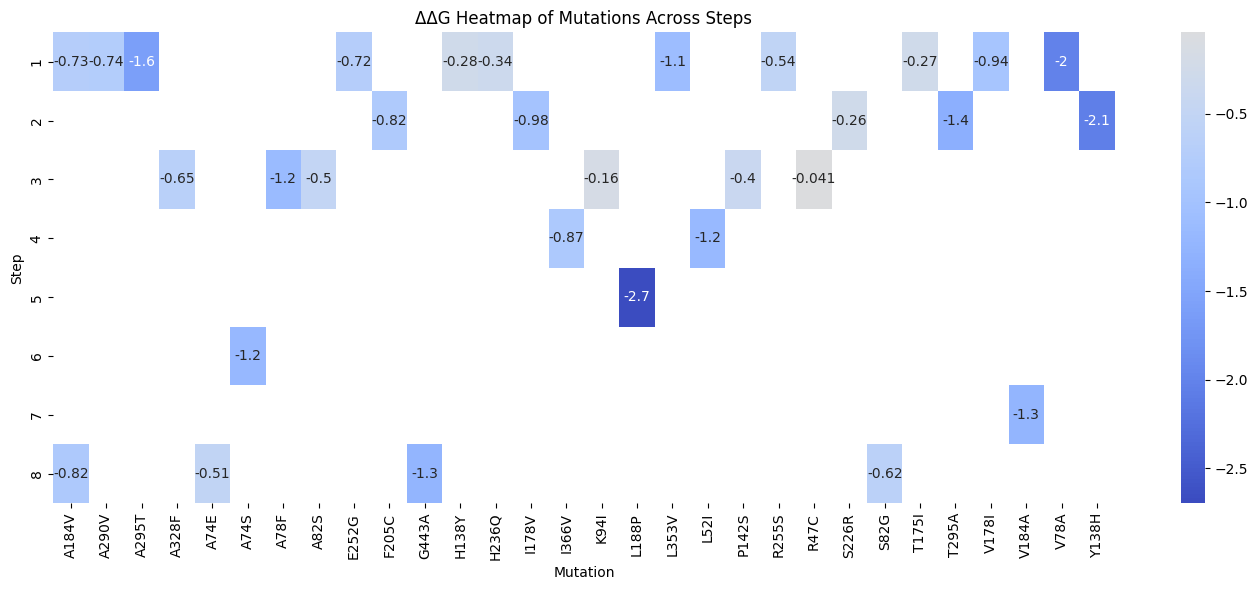

In [173]:
# Pivot table: steps as rows, mutations as columns
pivot = df.pivot(index="Step", columns="Mutation", values="ddG")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0)
plt.title("ΔΔG Heatmap of Mutations Across Steps")
plt.ylabel("Step")
plt.xlabel("Mutation")
plt.tight_layout()
plt.show()

In [174]:
# Compute step-wide average ΔΔG only for positions 1–460
step_avg_ddg = [np.mean(matrix[:460, :]) for matrix in ddg_matrices]

print(step_avg_ddg)

[-0.58598155, -0.59099793, -0.5859583, -0.5824387, -0.584674, -0.5826038, -0.58397174, -0.5831467]


In [175]:
ddg_matrices[4][188][12]

-2.2709737

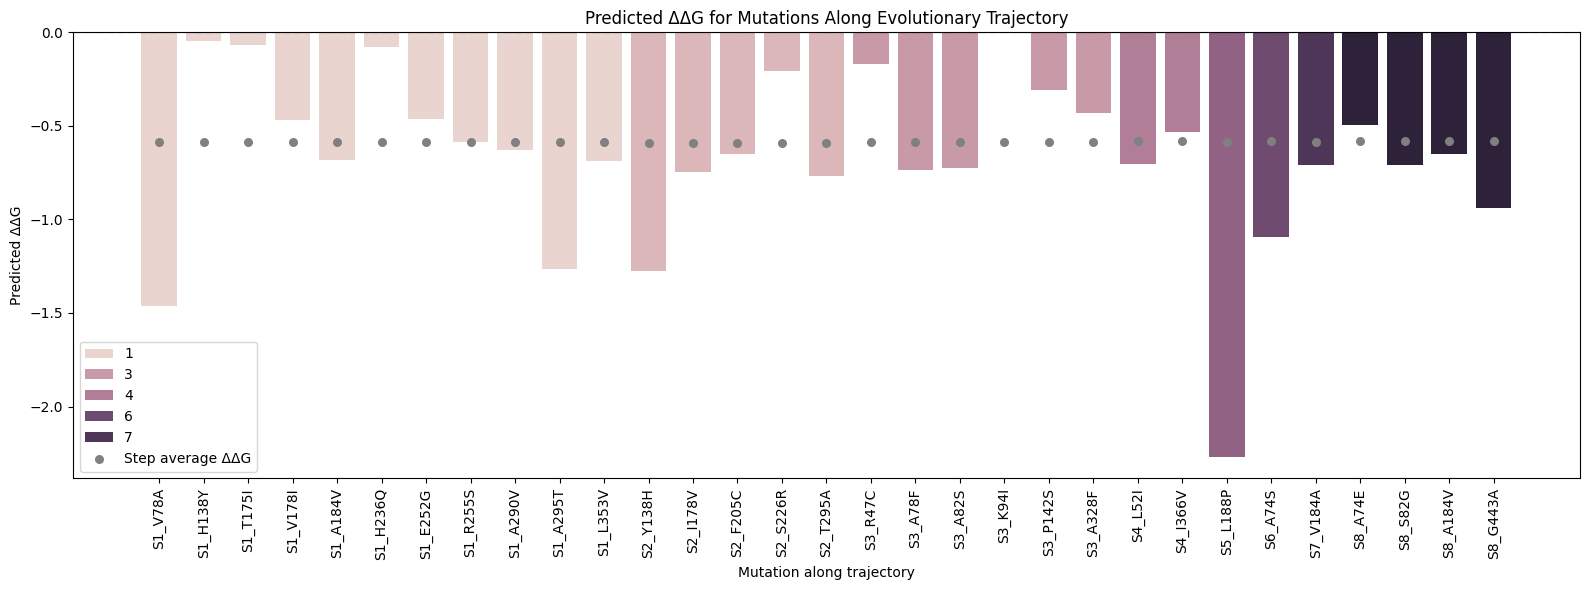

In [176]:
rows = []

# Prepare dataframe for bars
for step_idx, step_dict in enumerate(step_ddg):
    for mut, ddg in step_dict.items():
        rows.append({
            "Step": step_idx + 1,
            "Mutation": mut,
            "MutationStep": f"S{step_idx+1}_{mut}",  # keeps trajectory order
            "ddG": ddg
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(16,6))

# Barplot for individual mutation ΔΔG
sns.barplot(
    data=df,
    x="MutationStep",
    y="ddG",
    hue="Step",
    dodge=False
)

# Grey dots for step average ΔΔG
# Repeat each step average for the number of mutations in that step
avg_dots = []
for step_idx, step_dict in enumerate(step_ddg):
    n_mut = len(step_dict)
    avg_dots.extend([step_avg_ddg[step_idx]] * n_mut)

plt.scatter(
    range(len(df)),
    avg_dots,
    color="grey",
    s=30,        # smaller dot size
    zorder=5,
    label="Step average ΔΔG"
)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Predicted ΔΔG")
plt.xlabel("Mutation along trajectory")
plt.title("Predicted ΔΔG for Mutations Along Evolutionary Trajectory")
plt.legend()
plt.tight_layout()
plt.show()

In [177]:
# List to store the per-mutation averages (same shape as mutation_steps)
step_position_avg_ddg_list = []

for step_idx, mutations in enumerate(mutation_steps):
    matrix = ddg_matrices[step_idx]  # ΔΔG matrix for this step
    step_avg_list = []

    for mut in mutations:
        pos = int(mut[1:-1])  # convert position to 0-based index
        # average over all 20 amino acids at this position
        pos_mean = np.mean(matrix[pos, :]) #indices understand corectlz
        step_avg_list.append(pos_mean)

    step_position_avg_ddg_list.append(step_avg_list)

# step_position_avg_ddg_list now mirrors mutation_steps
print(step_position_avg_ddg_list)
print(np.mean(ddg_matrices[0][138]))
#print(wt_sequence[137])

[[-1.4116628, -0.33532906, -0.2815947, -1.2073288, -0.69029444, -0.20683229, -0.22183712, -0.48567095, -0.76991475, -1.1649169, -1.0758796], [-1.1891247, -1.2603029, -1.3014523, -0.22563505, -0.86324024], [-0.6340066, -1.1648308, -0.8732211, -0.15684964, -0.31224716, -0.44781032], [-1.0492303, -0.74726367], [-1.6894503], [-1.0478674], [-0.82053137], [-0.48049253, -0.43287158, -0.646402, -1.1144383]]
-0.33532906


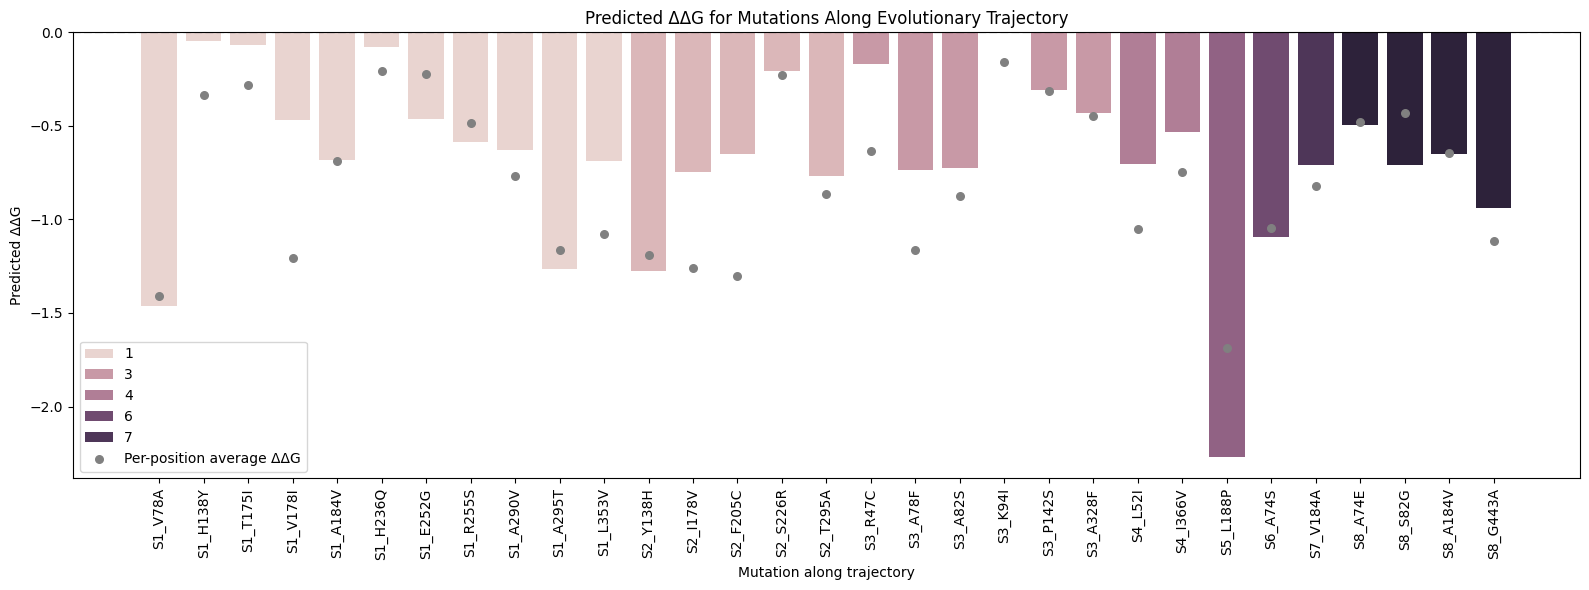

In [178]:

# Example: your step_ddg (mutation ΔΔG) and step_position_avg_ddg_list are ready
# step_ddg = [{mutation: ddG, ...}, ...]  # per step
# step_position_avg_ddg_list = [[avg1, avg2, ...], ...]  # per step, per mutation

rows = []

# Build DataFrame
for step_idx, step_dict in enumerate(step_ddg):
    for mut_idx, (mut, ddg) in enumerate(step_dict.items()):
        # get the per-position average from step_position_avg_ddg_list
        pos_avg = step_position_avg_ddg_list[step_idx][mut_idx]

        rows.append({
            "Step": step_idx + 1,
            "Mutation": mut,
            "MutationStep": f"S{step_idx+1}_{mut}",  # ensures trajectory order
            "ddG": ddg,
            "PosAvg": pos_avg
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(16,6))

# Barplot of individual mutation ΔΔG
sns.barplot(
    data=df,
    x="MutationStep",
    y="ddG",
    hue="Step",
    dodge=False
)

# Overlay grey dots for per-position average
plt.scatter(
    range(len(df)),
    df["PosAvg"],
    color="grey",
    s=30,        # smaller dot size
    zorder=5,
    label="Per-position average ΔΔG"
)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Predicted ΔΔG")
plt.xlabel("Mutation along trajectory")
plt.title("Predicted ΔΔG for Mutations Along Evolutionary Trajectory")
plt.legend()
plt.tight_layout()
plt.show()

In [179]:
step_position_err_list = []

for step_idx, mutations in enumerate(mutation_steps):
    matrix = ddg_matrices[step_idx]
    step_err_list = []

    for mut in mutations:
        pos = int(mut[1:-1]) - 1  # 0-based index
        ddg_values = matrix[pos, :]
        pos_std = np.std(ddg_values)           # standard deviation
        # or use SEM if preferred: pos_std = np.std(ddg_values)/np.sqrt(len(ddg_values))
        step_err_list.append(pos_std)

    step_position_err_list.append(step_err_list)

print(step_position_err_list)

[[0.53264695, 0.22565372, 0.42183977, 0.5322702, 0.22906205, 0.39740074, 0.21222435, 0.33903435, 0.32212764, 0.38693848, 0.25764483], [0.26783386, 0.5078446, 0.33422658, 0.27154958, 0.37611958], [0.22941545, 0.4737451, 0.30936992, 0.25493836, 0.38197887, 0.2518038], [0.4232683, 0.31389895], [0.34695625], [0.24969998], [0.26058117], [0.22616206, 0.31109822, 0.2280441, 0.25864255]]


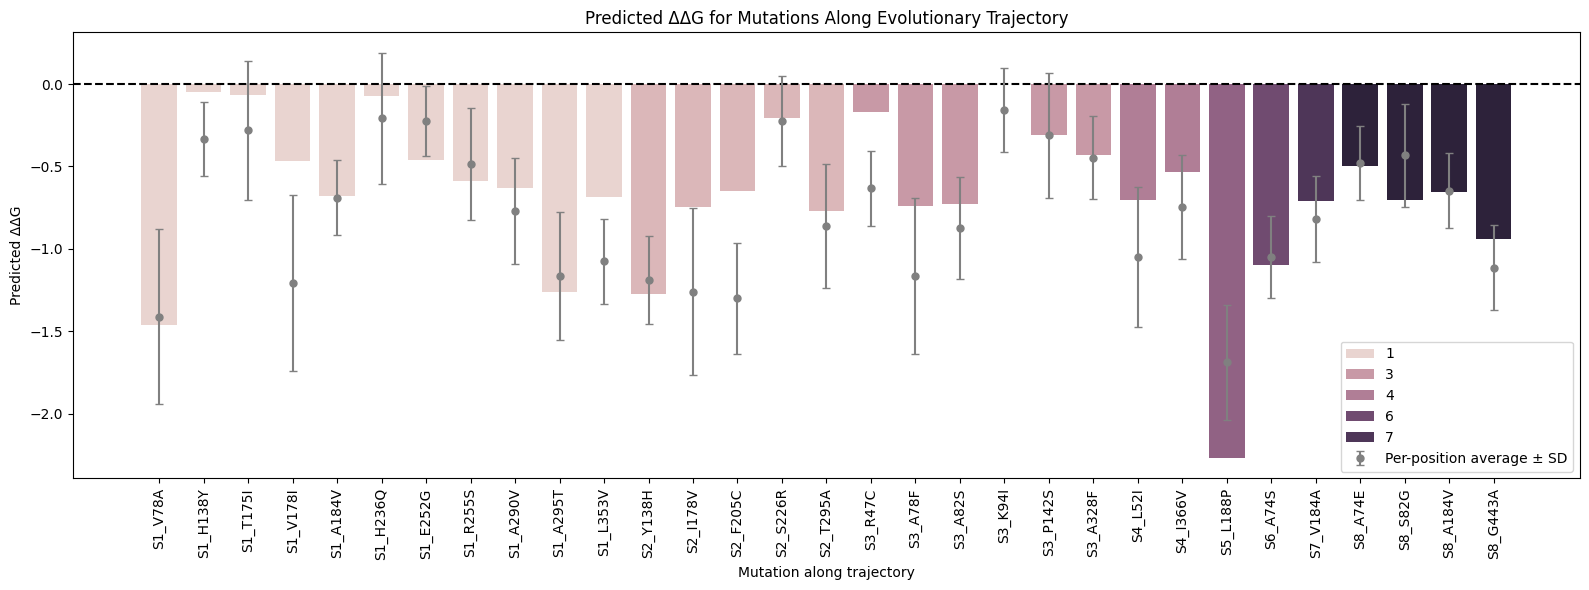

In [180]:

# Flatten the per-position averages and errors to match df row order
pos_avg_flat = [avg for step in step_position_avg_ddg_list for avg in step]
pos_err_flat = [err for step in step_position_err_list for err in step]

rows = []

# Build DataFrame for bars
for step_idx, step_dict in enumerate(step_ddg):
    for mut_idx, (mut, ddg) in enumerate(step_dict.items()):
        rows.append({
            "Step": step_idx + 1,
            "Mutation": mut,
            "MutationStep": f"S{step_idx+1}_{mut}",  # ensures trajectory order
            "ddG": ddg,
            "PosAvg": pos_avg_flat.pop(0),           # get corresponding average
            "PosErr": pos_err_flat.pop(0)           # get corresponding error
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(16,6))

# Barplot of individual mutation ΔΔG
sns.barplot(
    data=df,
    x="MutationStep",
    y="ddG",
    hue="Step",
    dodge=False
)

# Overlay grey dots with error bars for per-position averages
plt.errorbar(
    x=np.arange(len(df)),
    y=df["PosAvg"],
    yerr=df["PosErr"],
    fmt='o',          # dot
    color='grey',
    markersize=5,     # smaller dot
    capsize=3,        # little horizontal lines at ends of error bars
    label="Per-position average ± SD",
    zorder=5
)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Predicted ΔΔG")
plt.xlabel("Mutation along trajectory")
plt.title("Predicted ΔΔG for Mutations Along Evolutionary Trajectory")
plt.legend()
plt.tight_layout()
plt.show()

In [181]:
import random

def randomize_mutation_steps_limited(mutation_steps, sequence, aa_alphabet=aa_alphabet, max_pos=460):
    """
    Randomize mutation steps but limit positions between 1 and max_pos.

    Parameters:
        mutation_steps : list of lists
            Original mutation step structure (list of mutation strings)
        sequence : str
            WT sequence for reference
        aa_alphabet : str
            Standard amino acids (default 20)
        max_pos : int
            Maximum allowed position for random mutations (1-based)

    Returns:
        list of lists : same format as mutation_steps with random mutations
    """
    randomized_steps = []

    for step in mutation_steps:
        step_mutations = []
        for _ in step:  # preserve the number of mutations in this step
            pos = random.randint(0, max_pos - 1)  # 0-based index
            wt_aa = sequence[pos]
            mut_aa = random.choice([aa for aa in aa_alphabet if aa != wt_aa])
            mutation_str = f"{wt_aa}{pos+1}{mut_aa}"  # 1-based for string
            step_mutations.append(mutation_str)
        randomized_steps.append(step_mutations)

    return randomized_steps


In [182]:
random_steps = randomize_mutation_steps_limited(mutation_steps, wt_sequence, max_pos=460)

for i, step in enumerate(random_steps):
    print(f"Step {i+1}: {step}")

Step 1: ['R376C', 'L334K', 'Y257N', 'L342N', 'T92N', 'D426K', 'V287I', 'I154Q', 'K70H', 'V372M', 'L58G']
Step 2: ['F68R', 'P377M', 'T236L', 'K60L', 'L273N']
Step 3: ['S384T', 'E14N', 'A390D', 'H286C', 'V303P', 'F88Q']
Step 4: ['F406H', 'R51I']
Step 5: ['E353C']
Step 6: ['A336D']
Step 7: ['K225A']
Step 8: ['Y335M', 'V446R', 'G272L', 'K188W']


In [183]:
step_ddg_random = []

for step_idx, step_mutations in enumerate(random_steps):
    ddg_matrix = ddg_matrices[step_idx]  # CNN output for sequence at previous step
    step_dict = {}
    for mut in step_mutations:
        pos = int(mut[1:-1])
        aa_idx = aa_to_int[mut[-1]]
        step_dict[mut] = ddg_matrix[pos, aa_idx]
    step_ddg_random.append(step_dict)

print(step_ddg_random)

[{'R376C': -0.27170268, 'L334K': -1.738885, 'Y257N': -0.2958119, 'L342N': -1.0364887, 'T92N': -0.5872698, 'D426K': -0.07140366, 'V287I': -0.48054993, 'I154Q': -0.53229743, 'K70H': -0.35901538, 'V372M': -0.04177484, 'L58G': -1.749546}, {'F68R': -0.054209203, 'P377M': -0.05253385, 'T236L': 0.10224098, 'K60L': 0.032863222, 'L273N': -1.0764968}, {'S384T': -0.20219761, 'E14N': -1.465801, 'A390D': -2.583792, 'H286C': -0.08347012, 'V303P': -1.4817125, 'F88Q': -0.63989276}, {'F406H': -0.41812977, 'R51I': -0.44725272}, {'E353C': -0.27256504}, {'A336D': -0.5708794}, {'K225A': -0.34979475}, {'Y335M': -0.4029718, 'V446R': -1.2698723, 'G272L': -0.8359057, 'K188W': -0.68338746}]


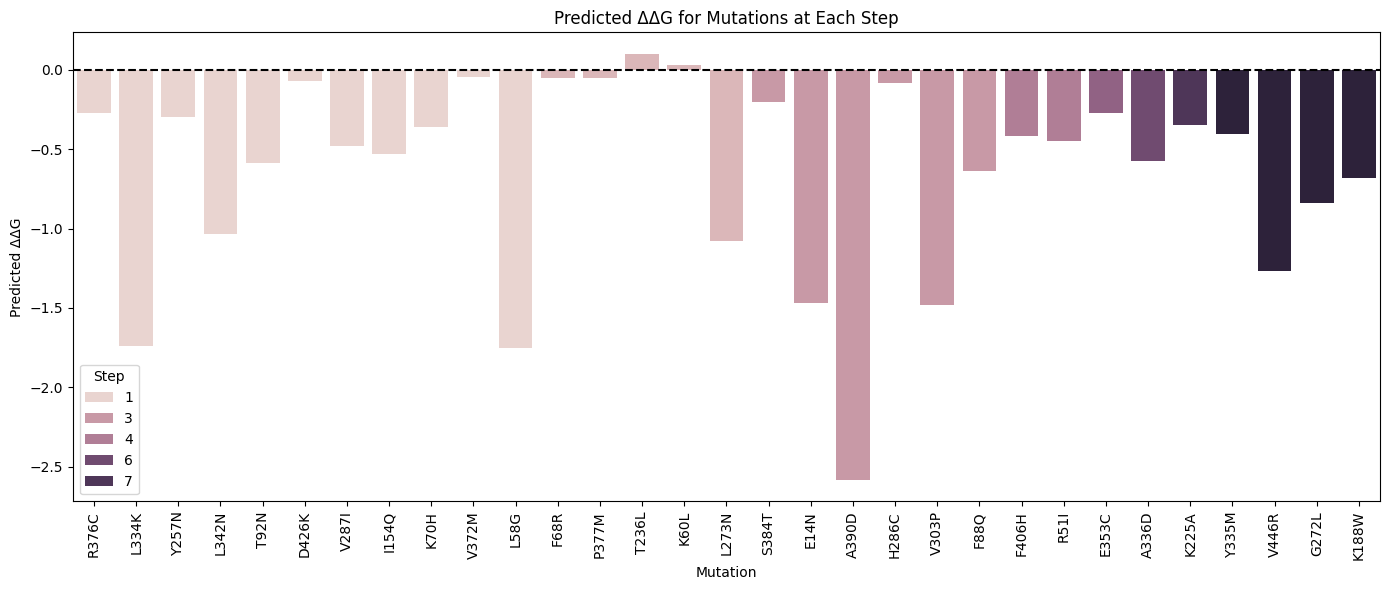

In [184]:
#Illustration:
rows = []
for step_idx, step_dict in enumerate(step_ddg_random):
    for mut, ddg in step_dict.items():
        rows.append({"Step": step_idx+1, "Mutation": mut, "ddG": ddg})

df = pd.DataFrame(rows)

plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Mutation", y="ddG", hue="Step", dodge=False)
plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')  # zero reference
plt.ylabel("Predicted ΔΔG")
plt.title("Predicted ΔΔG for Mutations at Each Step")
plt.legend(title="Step")
plt.tight_layout()
plt.show()

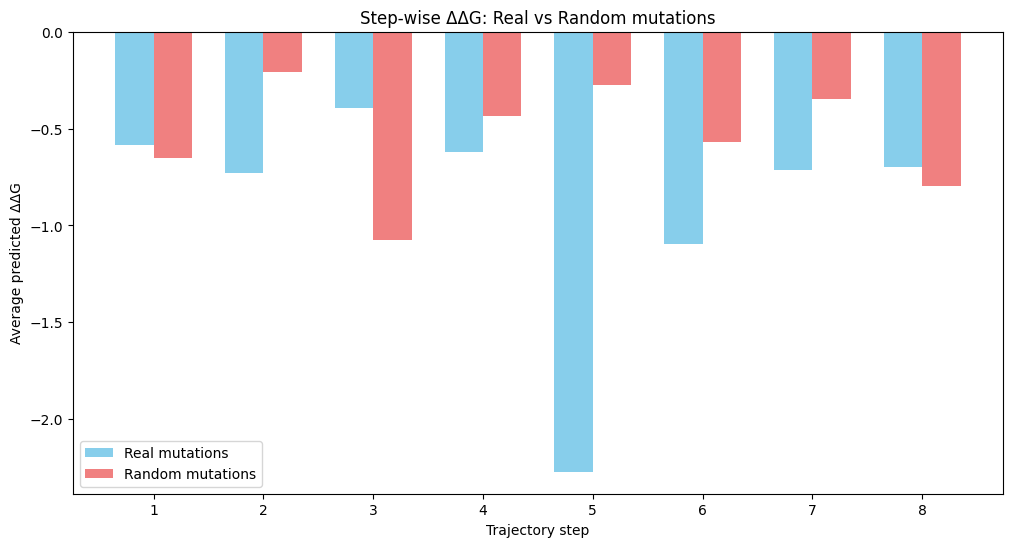

In [185]:
step_ddg  # list of dicts per step for actual mutations
step_ddg_random # list of dicts per step for random mutations

# Compute average ΔΔG per step
avg_real = [np.mean(list(d.values())) for d in step_ddg]
avg_random = [np.mean(list(d.values())) for d in step_ddg_random]

steps = np.arange(1, len(step_ddg)+1)

width = 0.35  # bar width

plt.figure(figsize=(12,6))
plt.bar(steps - width/2, avg_real, width, label='Real mutations', color='skyblue')
plt.bar(steps + width/2, avg_random, width, label='Random mutations', color='lightcoral')

plt.xlabel('Trajectory step')
plt.ylabel('Average predicted ΔΔG')
plt.title('Step-wise ΔΔG: Real vs Random mutations')
plt.xticks(steps)
plt.legend()
plt.show()

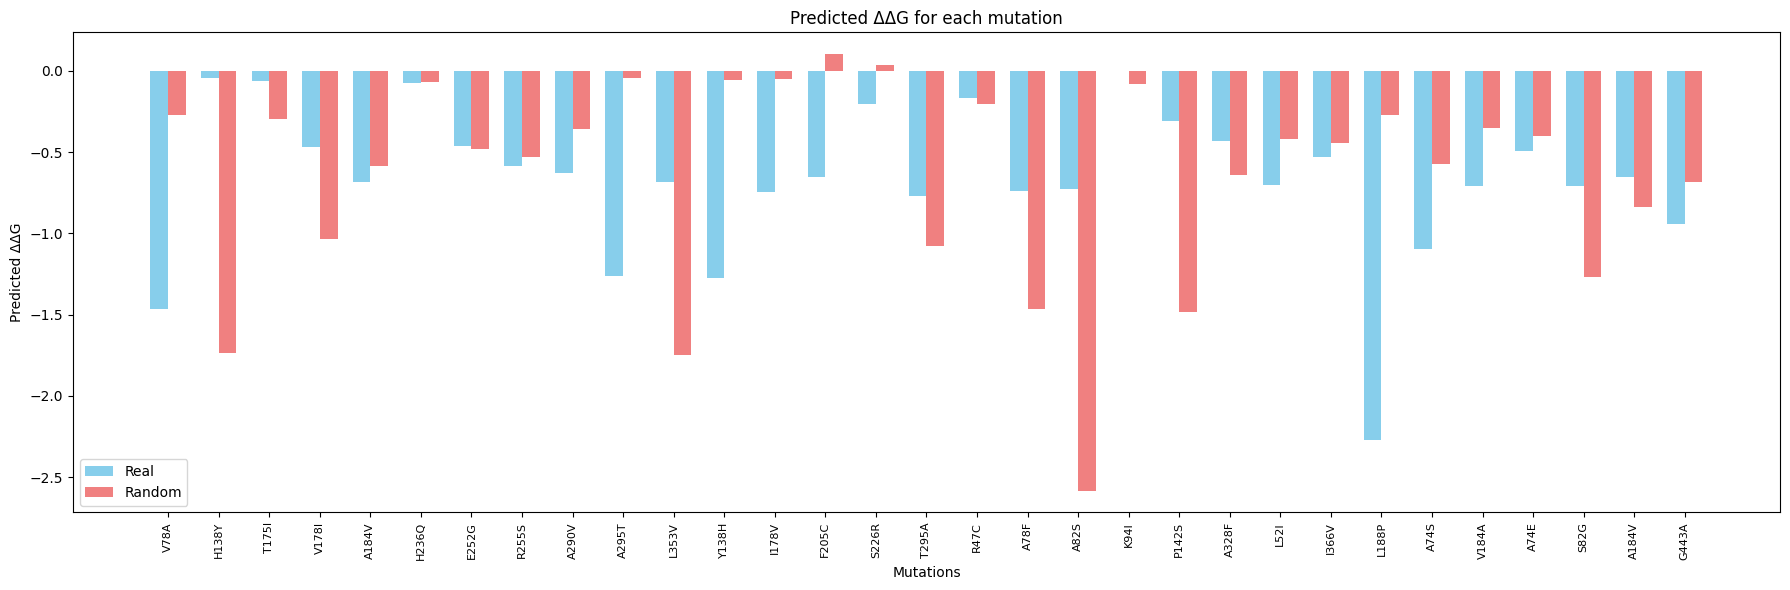

In [186]:
# Flatten real and random ΔΔG dictionaries
mutations_real = [mut for step in step_ddg for mut in step.keys()]
ddg_real = [val for step in step_ddg for val in step.values()]

mutations_random = [mut for step in step_ddg_random for mut in step.keys()]
ddg_random = [val for step in step_ddg_random for val in step.values()]

x = np.arange(len(mutations_real))
width = 0.35

plt.figure(figsize=(18,6))
plt.bar(x - width/2, ddg_real, width, label='Real', color='skyblue')
plt.bar(x + width/2, ddg_random, width, label='Random', color='lightcoral')

plt.xlabel('Mutations')
plt.ylabel('Predicted ΔΔG')
plt.title('Predicted ΔΔG for each mutation')
plt.xticks(x, mutations_real, rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

In [187]:
def average_ddg_random_mutations(matrix, step_sequence, num_random=50, max_pos=460, aa_alphabet=aa_alphabet):
    """
    Calculate average ΔΔG of num_random random mutations in the sequence at a given step,
    limited to positions 1..max_pos, using the ΔΔG matrix for that step.

    Parameters:
        matrix : np.ndarray
            ΔΔG matrix for the step (L x 20)
        step_sequence : str
            Sequence at the current trajectory step (includes accumulated mutations)
        num_random : int
            Number of random mutations to sample
        max_pos : int
            Maximum allowed position for mutation
        aa_alphabet : str
            Alphabet of amino acids

    Returns:
        float : average ΔΔG across random mutations
    """
    ddg_values = []

    for _ in range(num_random):
        # pick a random position <= max_pos
        pos = np.random.randint(0, max_pos)  # 0-based
        current_aa = step_sequence[pos]      # use AA at this trajectory step
        # pick a random mutation != current AA
        mut_aa = np.random.choice([aa for aa in aa_alphabet if aa != current_aa])
        # ΔΔG from matrix
        ddg_values.append(matrix[pos, aa_to_int[mut_aa]])

    return np.mean(ddg_values)

In [188]:
# trajectory = build_mutation_trajectory(wt_sequence, mutation_steps, shift=1)

avg_ddg_random_steps = []

for step_idx, matrix in enumerate(ddg_matrices):
    step_seq = trajectory[step_idx]  # sequence at this trajectory step
    avg_ddg = average_ddg_random_mutations(
        matrix,
        step_seq,
        num_random=50,
        max_pos=460
    )
    avg_ddg_random_steps.append(avg_ddg)

print("Average ΔΔG of 50 random mutations per trajectory step:")
print(avg_ddg_random_steps)
print(step_ddg)

Average ΔΔG of 50 random mutations per trajectory step:
[-0.561149, -0.67588454, -0.5679152, -0.47975284, -0.5899922, -0.59392416, -0.53633416, -0.636875]
[{'V78A': -1.4630576, 'H138Y': -0.04575772, 'T175I': -0.06552195, 'V178I': -0.46738818, 'A184V': -0.68159765, 'H236Q': -0.075788446, 'E252G': -0.46361044, 'R255S': -0.5858655, 'A290V': -0.6291439, 'A295T': -1.2626944, 'L353V': -0.6858464}, {'Y138H': -1.2767563, 'I178V': -0.74641585, 'F205C': -0.65194327, 'S226R': -0.20711364, 'T295A': -0.7694601}, {'R47C': -0.16856298, 'A78F': -0.73754, 'A82S': -0.72562414, 'K94I': -0.0026294212, 'P142S': -0.30963916, 'A328F': -0.43312737}, {'L52I': -0.70546585, 'I366V': -0.5329627}, {'L188P': -2.2709737}, {'A74S': -1.0955018}, {'V184A': -0.7116027}, {'A74E': -0.4955557, 'S82G': -0.70645154, 'A184V': -0.6524334, 'G443A': -0.94147784}]


Slope = 0.853, Intercept = -0.633, R^2 = 0.868


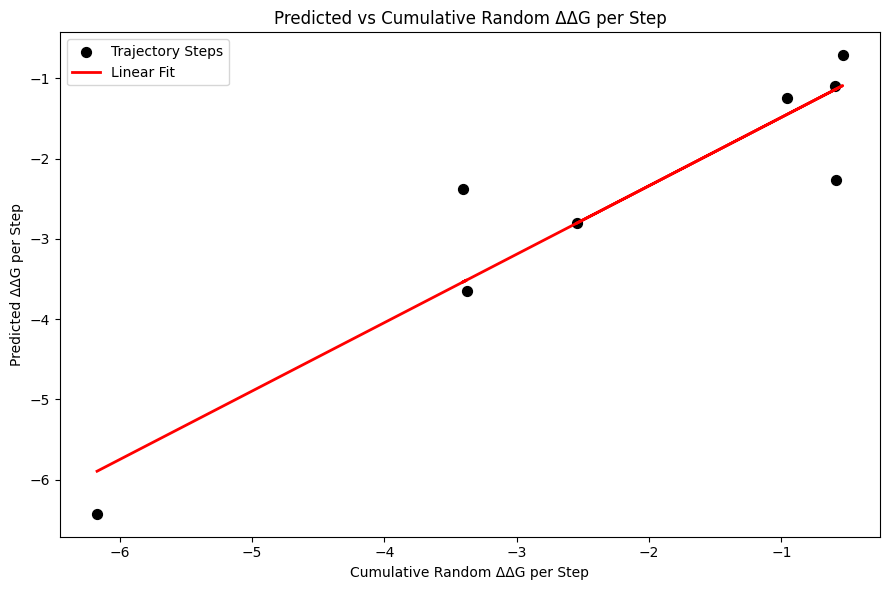

In [200]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Step-level predicted ΔΔG: sum of all mutations in step
y_pred = np.array([sum(list(step.values())) for step in step_ddg])

# Step-level random ΔΔG: average random ΔΔG * number of mutations at this step
x_rand_cumulative = np.array([
    avg_ddg_random_steps[i] * len(mutation_steps[i])
    for i in range(len(mutation_steps))
])

# Fit linear regression
modelL = LinearRegression()
modelL.fit(x_rand_cumulative.reshape(-1, 1), y_pred)
y_fit = modelL.predict(x_rand_cumulative.reshape(-1, 1))

# Metrics
r2 = r2_score(y_pred, y_fit)
print(f"Slope = {modelL.coef_[0]:.3f}, Intercept = {modelL.intercept_:.3f}, R^2 = {r2:.3f}")

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(x_rand_cumulative, y_pred, color='black', s=50, label='Trajectory Steps')
plt.plot(x_rand_cumulative, y_fit, color='red', linewidth=2, label='Linear Fit')
plt.xlabel("Cumulative Random ΔΔG per Step")
plt.ylabel("Predicted ΔΔG per Step")
plt.title("Predicted vs Cumulative Random ΔΔG per Step")
plt.legend()
plt.tight_layout()
plt.show()

Slope = 0.853, Intercept = -0.633, R^2 = 0.868, p-value = 0.001


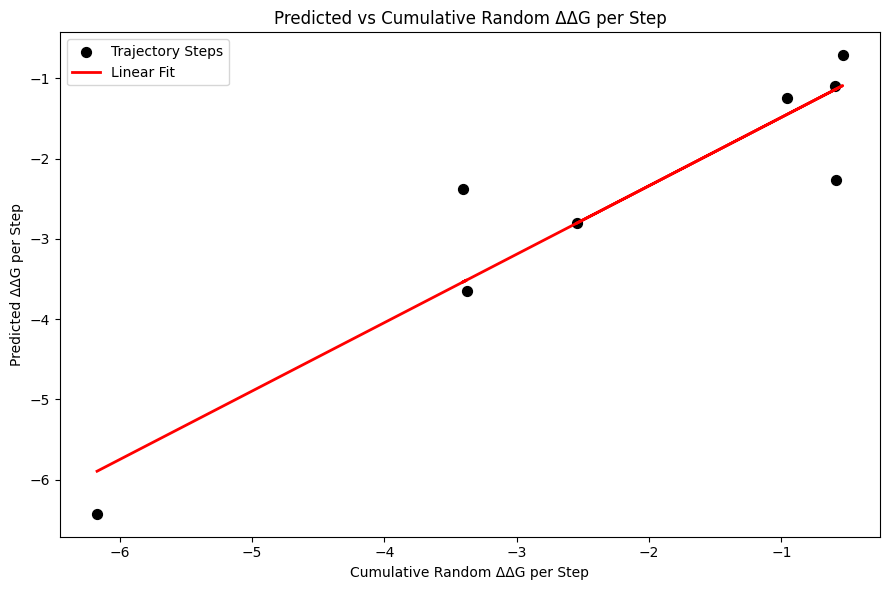

In [201]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
import matplotlib.pyplot as plt

# Step-level predicted ΔΔG: sum of all mutations in step
y_pred = np.array([sum(list(step.values())) for step in step_ddg])

# Step-level cumulative random ΔΔG
x_rand_cumulative = np.array([avg_ddg_random_steps[i] * len(mutation_steps[i])
                              for i in range(len(mutation_steps))])

# Fit linear regression
modelL = LinearRegression()
modelL.fit(x_rand_cumulative.reshape(-1,1), y_pred)
y_fit = modelL.predict(x_rand_cumulative.reshape(-1,1))

# Metrics
r2 = r2_score(y_pred, y_fit)
slope = modelL.coef_[0]
intercept = modelL.intercept_

# Compute standard error of the slope
n = len(x_rand_cumulative)           # number of points
x_mean = np.mean(x_rand_cumulative)
residuals = y_pred - y_fit
s_err = np.sqrt(np.sum(residuals**2) / (n-2))  # standard error of estimate
s_xx = np.sum((x_rand_cumulative - x_mean)**2)
slope_se = s_err / np.sqrt(s_xx)

# t-statistic for slope
t_stat = slope / slope_se

# two-sided p-value
p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n-2))

print(f"Slope = {slope:.3f}, Intercept = {intercept:.3f}, R^2 = {r2:.3f}, p-value = {p_value:.3f}")

# Plot
plt.figure(figsize=(9,6))
plt.scatter(x_rand_cumulative, y_pred, color='black', s=50, label='Trajectory Steps')
plt.plot(x_rand_cumulative, y_fit, color='red', linewidth=2, label='Linear Fit')
plt.xlabel("Cumulative Random ΔΔG per Step")
plt.ylabel("Predicted ΔΔG per Step")
plt.title("Predicted vs Cumulative Random ΔΔG per Step")
plt.legend()
plt.tight_layout()
plt.show()

In [195]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Step-level predicted ΔΔG
y_pred = np.array([sum(list(step.values())) for step in step_ddg])

# Step-level cumulative random ΔΔG
x_rand_cumulative = np.array([avg_ddg_random_steps[i] * len(mutation_steps[i]) 
                               for i in range(len(mutation_steps))])

# Pearson correlation (linear)
pearson_corr, pearson_p = pearsonr(x_rand_cumulative, y_pred)

# Spearman correlation (rank/monotonic)
spearman_corr, spearman_p = spearmanr(x_rand_cumulative, y_pred)

print(f"Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.3f}")
print(f"Spearman rho = {spearman_corr:.3f}, p-value = {spearman_p:.3f}")

Pearson r = 0.931, p-value = 0.001
Spearman rho = 0.857, p-value = 0.007


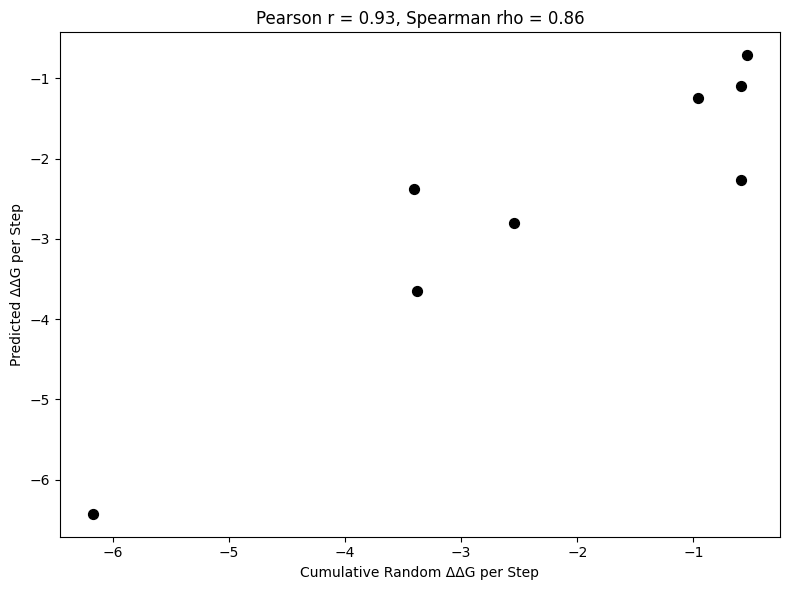

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(x_rand_cumulative, y_pred, color='black', s=50)
plt.xlabel("Cumulative Random ΔΔG per Step")
plt.ylabel("Predicted ΔΔG per Step")
plt.title(f"Pearson r = {pearson_corr:.2f}, Spearman rho = {spearman_corr:.2f}")
plt.tight_layout()
plt.show()

Slope = 1.476, Intercept = -0.032, R^2 = 0.022


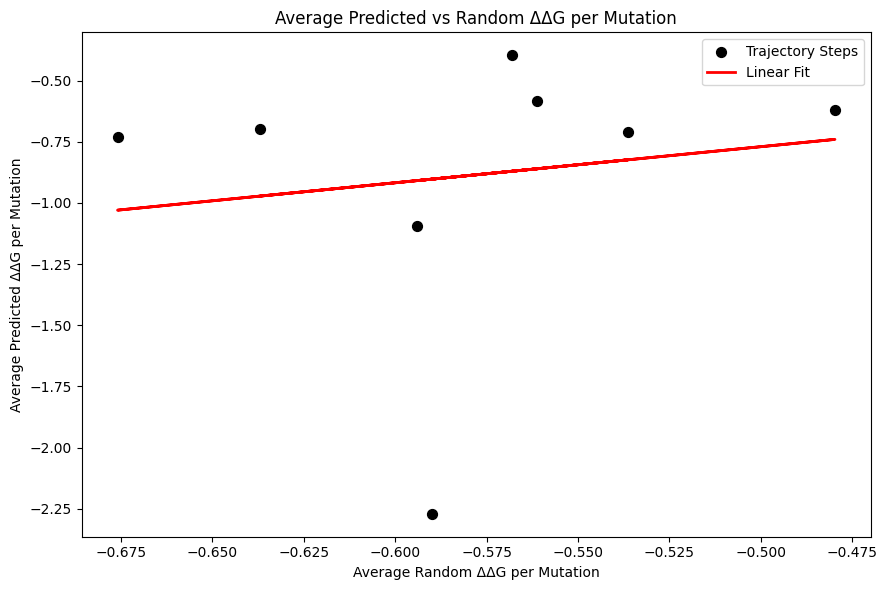

In [198]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Step-level predicted ΔΔG: average per mutation in step
y_avg_pred = np.array([
    np.mean(list(step.values()))  # average ΔΔG of all mutations in this step
    for step in step_ddg
])

# Step-level random ΔΔG: just the average random ΔΔG per mutation (no cumulative)
x_rand_avg = np.array(avg_ddg_random_steps)  # already average per step

# Fit linear regression
modelL = LinearRegression()
modelL.fit(x_rand_avg.reshape(-1, 1), y_avg_pred)
y_fit = modelL.predict(x_rand_avg.reshape(-1, 1))

# Metrics
r2 = r2_score(y_avg_pred, y_fit)
print(f"Slope = {modelL.coef_[0]:.3f}, Intercept = {modelL.intercept_:.3f}, R^2 = {r2:.3f}")

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(x_rand_avg, y_avg_pred, color='black', s=50, label='Trajectory Steps')
plt.plot(x_rand_avg, y_fit, color='red', linewidth=2, label='Linear Fit')
plt.xlabel("Average Random ΔΔG per Mutation")
plt.ylabel("Average Predicted ΔΔG per Mutation")
plt.title("Average Predicted vs Random ΔΔG per Mutation")
plt.legend()
plt.tight_layout()
plt.show()

Pearson r = 0.149, p-value = 0.724


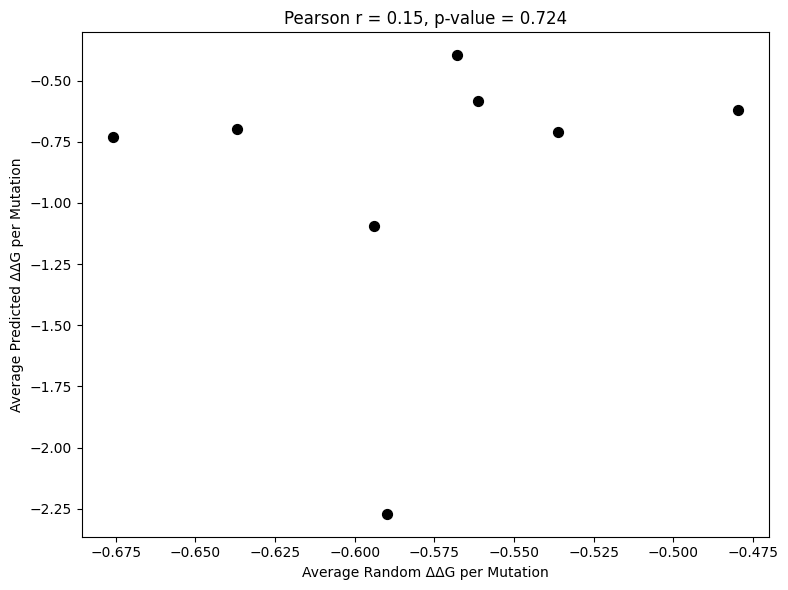

In [199]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# Step-level predicted ΔΔG per mutation
y_avg_pred = np.array([np.mean(list(step.values())) for step in step_ddg])

# Step-level random ΔΔG per mutation
x_rand_avg = np.array(avg_ddg_random_steps)

# Pearson correlation and p-value
pearson_corr, pearson_p = pearsonr(x_rand_avg, y_avg_pred)

print(f"Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.3f}")

# Optional plot
plt.figure(figsize=(8,6))
plt.scatter(x_rand_avg, y_avg_pred, color='black', s=50)
plt.xlabel("Average Random ΔΔG per Mutation")
plt.ylabel("Average Predicted ΔΔG per Mutation")
plt.title(f"Pearson r = {pearson_corr:.2f}, p-value = {pearson_p:.3f}")
plt.tight_layout()
plt.show()